In [3]:
import numpy as np
import cv2

try:
    from google.colab.patches import cv2_imshow
except ImportError:
    import matplotlib.pyplot as plt

    def cv2_imshow(img):
        """Display OpenCV images in non-Colab notebooks."""
        if img is None:
            raise ValueError("cv2_imshow received None")
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


In [9]:
import os
from urllib.request import urlretrieve

# Model file names
face_proto = "opencv_face_detector.pbtxt"
face_model = "opencv_face_detector_uint8.pb"
age_proto = "age_deploy.prototxt"
age_model = "age_net.caffemodel"

# Download files if they are missing in the current working directory
model_urls = {
    face_proto: "https://raw.githubusercontent.com/spmallick/learnopencv/master/AgeGender/opencv_face_detector.pbtxt",
    face_model: "https://raw.githubusercontent.com/spmallick/learnopencv/master/AgeGender/opencv_face_detector_uint8.pb",
    age_proto: "https://raw.githubusercontent.com/GilLevi/AgeGenderDeepLearning/master/models/age_deploy.prototxt",
    age_model: "https://github.com/GilLevi/AgeGenderDeepLearning/raw/master/models/age_net.caffemodel",
}

for filename, url in model_urls.items():
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        urlretrieve(url, filename)

# Read models in OpenCV
face_net = cv2.dnn.readNetFromTensorflow(face_model, face_proto)
age_net = cv2.dnn.readNetFromCaffe(age_proto, age_model)

print("Models loaded successfully")

Models loaded successfully


In [10]:
#definning a fnction to detect the faces in the img frames
def detecting_faces(net, frame, conf_threshold= 0.7):
    #h and w of the frame
    h = frame.shape[0]
    w = frame.shape[1]

    blob = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), [104, 117, 123], False, False)
    net.setInput(blob)
    detections = net.forward()
    face_Boxes = []

    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > conf_threshold:
            x1 = int(detections[0, 0, i, 3] * w)
            y1 = int(detections[0, 0, i, 4] * h)
            x2 = int(detections[0, 0, i, 5] * w)
            y2 = int(detections[0, 0, i, 6] * h)
            face_Boxes.append([x1, y1, x2, y2])
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), int(round(h / 150)), 8)
    return frame, face_Boxes
    

In [20]:
# predicting the age
# crop the face -> pass forward to detect the age -> index with highest prob is the predicted age
MODEL_MEAN_VALUES = (78.4263377603, 87.7689143744, 114.895847746)
age_list = ['1-5', '5-10', '10-15', '15-20', '20-25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '60+']

def predicting_age(face, net):
    blob = cv2.dnn.blobFromImage(face, 1.0, (227, 227), MODEL_MEAN_VALUES, swapRB=False)
    net.setInput(blob)
    age_preds = net.forward()
    age = age_list[age_preds[0].argmax()]
    return age
    

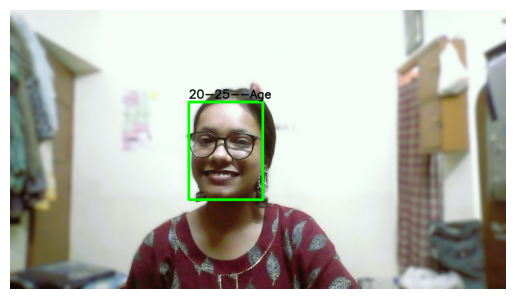

In [27]:
def process_img(img_path):
    frame = cv2.imread(img_path)

    if frame is None:
        print('image not found!')
        return None

    frame, face_boxes = detecting_faces(face_net, frame)

    for (x1, y1, x2, y2) in face_boxes:
        face = frame[max(0, y1-20):min(y2+20, frame.shape[0]-1), max(0, x1-20):min(x2+20, frame.shape[1]-1)]

        age = predicting_age(face, age_net)
        cv2.putText(frame, f"{age}--Age", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 2, cv2.LINE_AA)
        cv2_imshow(frame)

        cv2.waitKey(0)
        cv2.destroyAllWindows()

img_path = "me.png.jpg"
process_img(img_path)

In [28]:
#using webcam to capture the video and predict the age in real time
cap = cv2.VideoCapture(0)
while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to capture video")
        break

    frame, face_boxes = detecting_faces(face_net, frame)

    for (x1, y1, x2, y2) in face_boxes:
        face = frame[max(0, y1-20):min(y2+20, frame.shape[0]-1), max(0, x1-20):min(x2+20, frame.shape[1]-1)]
        age = predicting_age(face, age_net)
        cv2.putText(frame, f"{age}--Age", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2, cv2.LINE_AA)

    cv2.imshow("Age Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()


KeyboardInterrupt: 